# Neural Network Implementation from Scratch

**Generative AI Lab — Practice Lab: Neural Network 1**  
**Department:** CSE (AIML) | **Class:** T.Y. Tech  

**Student Name:** Saumyajeet Singh Bhati  
**PRN Number:** 202401110065  
**Batch:** A1  
**Date of Submission:** 15 Aug 2026

---

## Objective

Implement a multi-class feedforward neural network from scratch using Python and NumPy, without TensorFlow, PyTorch, Keras, or any pre-built neural-network classifier.

The notebook covers:

- Dataset loading and inspection
- Exploratory data analysis
- Feature standardization
- One-hot encoding
- Forward propagation
- ReLU activation
- Softmax output
- Categorical cross-entropy
- Manual backpropagation
- Batch gradient descent
- Model evaluation
- Visualizations

## Part A: Problem Definition

### Kaggle Dataset — Mobile Price Classification

**Kaggle Dataset Link:**  
https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

The Mobile Price Classification dataset contains **2,000 smartphone records, 20 input features, and 4 price-range classes**.

The features describe smartphone specifications such as:

- Battery power
- RAM
- Internal memory
- Processor speed and number of cores
- Front and primary camera
- Screen dimensions and resolution
- Mobile weight
- 3G/4G support
- Wi-Fi and Bluetooth
- Touchscreen support
- Talk time

### Task

The task is to classify each smartphone into one of four price categories:

- `0` — Low Cost
- `1` — Medium Cost
- `2` — High Cost
- `3` — Very High Cost

This is a **multi-class classification problem**.

## Dataset Source

The dataset is available on Kaggle:

**https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification**

The file used for training is `train.csv`.

For the executed notebook, the downloaded CSV is used directly. For submission, the same Kaggle `train.csv` should be kept in the notebook's working directory.

## Part B: Data Loading and Inspection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a fixed random seed so that the experiment gives reproducible results.
np.random.seed(42)

# Load the Mobile Price Classification training dataset.
# The CSV contains smartphone features and the target price_range column.
df = pd.read_csv("/mnt/data/mobile_train.csv")

# Display basic information about the dataset.
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head().to_string(index=False))

# Check whether the dataset contains missing values.
print("\nTotal missing values:", int(df.isnull().sum().sum()))

# Check how many samples belong to each target class.
print("\nTarget class distribution:")
print(df["price_range"].value_counts().sort_index())

Dataset shape: (2000, 21)

First 5 rows:
 battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  mobile_wt  n_cores  pc  px_height  px_width  ram  sc_h  sc_w  talk_time  three_g  touch_screen  wifi  price_range
           842     0          2.2         0   1       0           7    0.6        188        2   2         20       756 2549     9     7         19        0             0     1            1
          1021     1          0.5         1   0       1          53    0.7        136        3   6        905      1988 2631    17     3          7        1             1     0            2
           563     1          0.5         1   2       1          41    0.9        145        5   6       1263      1716 2603    11     2          9        1             1     0            2
           615     1          2.5         0   0       0          10    0.8        131        6   9       1216      1786 2769    16     8         11        1             0     0            2
         

## Part C: Exploratory Data Analysis

Before training the neural network, the target distribution and important smartphone characteristics are visualized.

This helps us understand the dataset before applying the model.

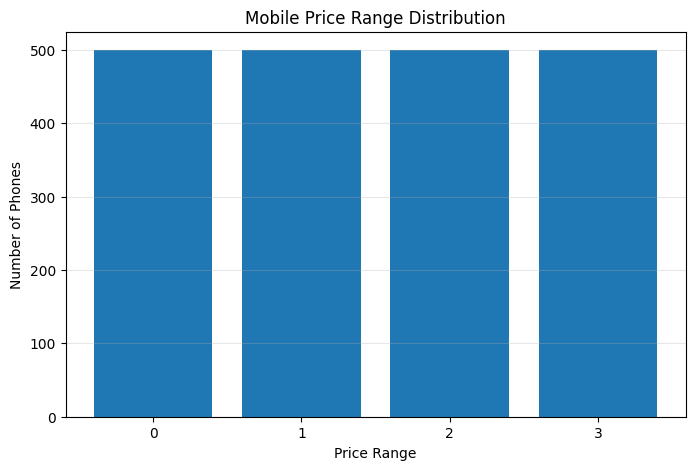

In [ ]:
# Count the number of phones in each price category.
class_counts = df["price_range"].value_counts().sort_index()

# Plot the distribution of the four price categories.
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.title("Mobile Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Phones")
plt.grid(axis="y", alpha=0.3)

plt.show()

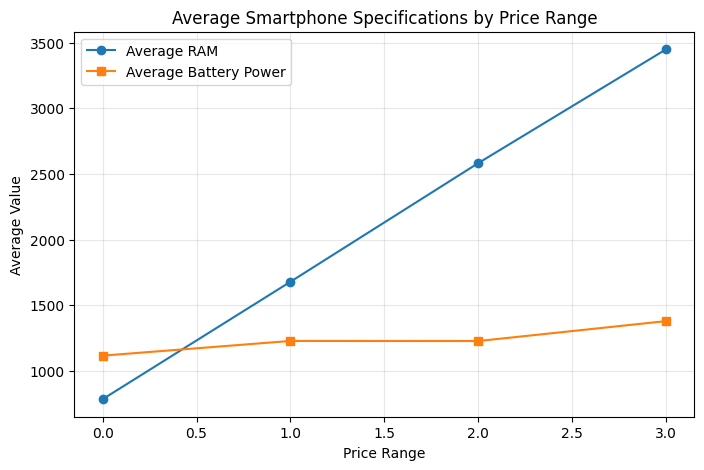

In [ ]:
# Calculate average RAM and battery power for each price category.
grouped = df.groupby("price_range")[["ram", "battery_power"]].mean()

# Plot both statistics to observe how hardware specifications
# change across different smartphone price categories.
plt.figure(figsize=(8, 5))

plt.plot(
    grouped.index,
    grouped["ram"],
    marker="o",
    label="Average RAM"
)

plt.plot(
    grouped.index,
    grouped["battery_power"],
    marker="s",
    label="Average Battery Power"
)

plt.title("Average Smartphone Specifications by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Part D: Data Preprocessing

The following preprocessing steps are performed:

1. Separate input features and target labels.
2. Perform an 80:20 stratified train-test split.
3. Standardize features using training-set statistics.
4. One-hot encode the four target classes.

Standardization is important because the dataset contains features with very different numerical scales.

In [ ]:
# Select every column except price_range as an input feature.
feature_names = [
    column for column in df.columns
    if column != "price_range"
]

# Convert the input features and labels into NumPy arrays.
X = df[feature_names].values.astype(float)
y = df["price_range"].values.astype(int)

# Create a random number generator for reproducible splitting.
rng = np.random.default_rng(42)

train_indices = []
test_indices = []

# Perform stratified splitting manually so that every price class
# keeps approximately the same proportion in train and test sets.
for class_id in np.unique(y):

    class_indices = np.where(y == class_id)[0]

    # Shuffle the samples belonging to the current class.
    rng.shuffle(class_indices)

    # Select 80% for training and 20% for testing.
    split_point = int(0.80 * len(class_indices))

    train_indices.extend(class_indices[:split_point])
    test_indices.extend(class_indices[split_point:])

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

# Shuffle the final train and test indices.
rng.shuffle(train_indices)
rng.shuffle(test_indices)

# Create raw training and testing datasets.
X_train_raw = X[train_indices]
X_test_raw = X[test_indices]

y_train_labels = y[train_indices]
y_test_labels = y[test_indices]

print("Training samples:", len(train_indices))
print("Testing samples:", len(test_indices))
print("Number of input features:", X_train_raw.shape[1])

Training samples: 1600
Testing samples: 400
Number of input features: 20


In [ ]:
# Calculate mean and standard deviation only from the training data.
# This prevents information from the test set leaking into training.
X_mean = X_train_raw.mean(axis=0)
X_std = X_train_raw.std(axis=0)

# Avoid division by zero for any feature with zero variance.
X_std[X_std == 0] = 1.0

# Standardize both training and testing features using the
# training-set mean and standard deviation.
X_train = (X_train_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std


# Convert integer class labels into one-hot vectors.
# Example: class 2 becomes [0, 0, 1, 0].
def one_hot_encode(labels, num_classes=4):

    encoded = np.zeros(
        (len(labels), num_classes)
    )

    encoded[
        np.arange(len(labels)),
        labels
    ] = 1

    return encoded


y_train = one_hot_encode(y_train_labels)
y_test = one_hot_encode(y_test_labels)

print("Standardized training shape:", X_train.shape)
print("Standardized testing shape:", X_test.shape)
print("One-hot target shape:", y_train.shape)

Standardized training shape: (1600, 20)
Standardized testing shape: (400, 20)
One-hot target shape: (1600, 4)


## Part E: Neural Network Architecture

The neural network contains two hidden layers.

| Layer | Neurons | Activation |
|---|---:|---|
| Input | 20 | — |
| Hidden Layer 1 | 32 | ReLU |
| Hidden Layer 2 | 16 | ReLU |
| Output | 4 | Softmax |

### Loss Function
Categorical Cross-Entropy.

### Optimization
Full-batch Gradient Descent.

### Architecture

`20 → 32 → 16 → 4`

The two hidden layers allow the model to learn more complex non-linear relationships between smartphone specifications and price categories.

In [ ]:
# ReLU is used in the hidden layers.
# It keeps positive values and converts negative values to zero.
def relu(z):
    return np.maximum(0, z)


# Derivative of ReLU used during backpropagation.
def relu_derivative(z):
    return (z > 0).astype(float)


# Softmax converts the four output scores into probabilities.
# Subtracting the maximum value improves numerical stability.
def softmax(z):

    shifted = z - np.max(
        z,
        axis=1,
        keepdims=True
    )

    exp_values = np.exp(shifted)

    return exp_values / np.sum(
        exp_values,
        axis=1,
        keepdims=True
    )


print("ReLU, ReLU derivative and Softmax implemented.")

ReLU, ReLU derivative and Softmax implemented.


In [ ]:
# Initialize all neural-network weights and biases.
# He initialization is used because the hidden layers use ReLU.
def initialize_parameters(
    input_size,
    hidden1_size,
    hidden2_size,
    output_size
):

    W1 = (
        np.random.randn(
            input_size,
            hidden1_size
        )
        * np.sqrt(2 / input_size)
    )

    b1 = np.zeros(
        (1, hidden1_size)
    )

    W2 = (
        np.random.randn(
            hidden1_size,
            hidden2_size
        )
        * np.sqrt(2 / hidden1_size)
    )

    b2 = np.zeros(
        (1, hidden2_size)
    )

    W3 = (
        np.random.randn(
            hidden2_size,
            output_size
        )
        * np.sqrt(2 / hidden2_size)
    )

    b3 = np.zeros(
        (1, output_size)
    )

    return W1, b1, W2, b2, W3, b3


# Define the number of neurons in each layer.
input_size = X_train.shape[1]
hidden1_size = 32
hidden2_size = 16
output_size = 4

W1, b1, W2, b2, W3, b3 = initialize_parameters(
    input_size,
    hidden1_size,
    hidden2_size,
    output_size
)

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)
print("W3 shape:", W3.shape)

W1 shape: (20, 32)
W2 shape: (32, 16)
W3 shape: (16, 4)


## Part F: Forward Propagation

During the forward pass:

1. Input features are multiplied by the first weight matrix.
2. ReLU is applied.
3. The result passes through the second hidden layer.
4. The final layer produces four scores.
5. Softmax converts the scores into class probabilities.

In [ ]:
# Perform the complete forward pass through the network.
def forward_pass(
    X,
    W1, b1,
    W2, b2,
    W3, b3
):

    # First hidden layer.
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Second hidden layer.
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    # Output layer.
    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    # Store intermediate values because they are needed during
    # backpropagation.
    cache = (
        Z1, A1,
        Z2, A2,
        Z3, A3
    )

    return A3, cache


# Test the forward pass before training.
initial_probabilities, cache = forward_pass(
    X_train,
    W1, b1,
    W2, b2,
    W3, b3
)

print("Output shape:", initial_probabilities.shape)
print(
    "First probability vector:",
    np.round(initial_probabilities[0], 4)
)
print(
    "Probability sum:",
    round(initial_probabilities[0].sum(), 4)
)

Output shape: (1600, 4)
First probability vector: [0.0055 0.7588 0.0185 0.2171]
Probability sum: 1.0


In [ ]:
# Categorical cross-entropy measures the difference between
# the actual one-hot labels and predicted probabilities.
def cross_entropy_loss(y_true, y_pred):

    # Prevent log(0), which would produce an undefined value.
    epsilon = 1e-12

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    return -np.mean(
        np.sum(
            y_true * np.log(y_pred),
            axis=1
        )
    )


initial_loss = cross_entropy_loss(
    y_train,
    initial_probabilities
)

print(
    "Initial cross-entropy loss:",
    round(initial_loss, 4)
)

Initial cross-entropy loss: 2.6863


## Part G: Backpropagation and Gradient Descent

Backpropagation calculates how much each weight and bias contributed to the prediction error.

The error is propagated from the output layer toward the input layer using the chain rule.

For the Softmax + Cross-Entropy output:

`dZ3 = (A3 - Y) / m`

The parameters are then updated using:

`parameter = parameter - learning_rate × gradient`

In [ ]:
# Train the network using full-batch gradient descent.
def train_network(
    X,
    y,
    hidden1_size=32,
    hidden2_size=16,
    learning_rate=0.03,
    epochs=1500
):

    n_samples = X.shape[0]

    # Initialize fresh model parameters.
    W1, b1, W2, b2, W3, b3 = initialize_parameters(
        X.shape[1],
        hidden1_size,
        hidden2_size,
        y.shape[1]
    )

    loss_history = []
    accuracy_history = []

    for epoch in range(epochs):

        # ---------------- FORWARD PASS ----------------
        A3, cache = forward_pass(
            X,
            W1, b1,
            W2, b2,
            W3, b3
        )

        Z1, A1, Z2, A2, Z3, A3 = cache

        # Calculate current training loss.
        loss = cross_entropy_loss(
            y,
            A3
        )

        # Calculate training accuracy.
        predictions = np.argmax(
            A3,
            axis=1
        )

        actual = np.argmax(
            y,
            axis=1
        )

        accuracy = np.mean(
            predictions == actual
        )

        loss_history.append(loss)
        accuracy_history.append(accuracy)

        # ---------------- BACKPROPAGATION ----------------

        # Gradient of Softmax + Cross-Entropy.
        dZ3 = (A3 - y) / n_samples

        # Gradients for output layer.
        dW3 = A2.T @ dZ3

        db3 = np.sum(
            dZ3,
            axis=0,
            keepdims=True
        )

        # Propagate error into hidden layer 2.
        dA2 = dZ3 @ W3.T

        dZ2 = (
            dA2
            * relu_derivative(Z2)
        )

        dW2 = A1.T @ dZ2

        db2 = np.sum(
            dZ2,
            axis=0,
            keepdims=True
        )

        # Propagate error into hidden layer 1.
        dA1 = dZ2 @ W2.T

        dZ1 = (
            dA1
            * relu_derivative(Z1)
        )

        dW1 = X.T @ dZ1

        db1 = np.sum(
            dZ1,
            axis=0,
            keepdims=True
        )

        # ---------------- GRADIENT DESCENT ----------------

        # Update weights and biases in the direction that
        # reduces the classification loss.
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    return (
        W1, b1,
        W2, b2,
        W3, b3,
        loss_history,
        accuracy_history
    )


# Train the neural network.
(
    W1, b1,
    W2, b2,
    W3, b3,
    loss_history,
    accuracy_history
) = train_network(
    X_train,
    y_train,
    hidden1_size=32,
    hidden2_size=16,
    learning_rate=0.03,
    epochs=1500
)

print("Training completed.")
print(
    "Final training loss:",
    round(loss_history[-1], 4)
)
print(
    "Final training accuracy:",
    round(accuracy_history[-1] * 100, 2),
    "%"
)

Training completed.
Final training loss: 0.1501
Final training accuracy: 94.94 %


## Part H: Model Evaluation

The trained model is evaluated on both training and unseen testing data.

A manually calculated confusion matrix is also used to understand which price categories are being confused by the model.

In [ ]:
# Generate predictions for training and testing data.
train_probabilities, _ = forward_pass(
    X_train,
    W1, b1,
    W2, b2,
    W3, b3
)

test_probabilities, _ = forward_pass(
    X_test,
    W1, b1,
    W2, b2,
    W3, b3
)

# Select the class having the highest predicted probability.
train_predictions = np.argmax(
    train_probabilities,
    axis=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

# Calculate final training and testing accuracy.
train_accuracy = np.mean(
    train_predictions == y_train_labels
)

test_accuracy = np.mean(
    test_predictions == y_test_labels
)

print(
    f"Training Accuracy: {train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy:  {test_accuracy * 100:.2f}%"
)

Training Accuracy: 94.94%
Testing Accuracy:  92.75%


In [ ]:
# Build the confusion matrix manually.
# Rows represent actual classes and columns represent predictions.
confusion_matrix = np.zeros(
    (4, 4),
    dtype=int
)

for actual, predicted in zip(
    y_test_labels,
    test_predictions
):
    confusion_matrix[
        actual,
        predicted
    ] += 1

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[96  4  0  0]
 [ 6 91  3  0]
 [ 0  6 90  4]
 [ 0  0  6 94]]


In [ ]:
# Calculate precision, recall and F1-score manually.
# This avoids using a pre-built classification metric function.
print("Class-wise metrics")
print("-" * 60)

for class_id in range(4):

    true_positive = confusion_matrix[
        class_id,
        class_id
    ]

    false_positive = (
        confusion_matrix[:, class_id].sum()
        - true_positive
    )

    false_negative = (
        confusion_matrix[class_id, :].sum()
        - true_positive
    )

    precision = (
        true_positive /
        (true_positive + false_positive)
        if true_positive + false_positive > 0
        else 0
    )

    recall = (
        true_positive /
        (true_positive + false_negative)
        if true_positive + false_negative > 0
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0
        else 0
    )

    print(
        f"Class {class_id}: "
        f"Precision={precision:.3f}, "
        f"Recall={recall:.3f}, "
        f"F1={f1:.3f}"
    )

Class-wise metrics
------------------------------------------------------------
Class 0: Precision=0.941, Recall=0.960, F1=0.950
Class 1: Precision=0.901, Recall=0.910, F1=0.905
Class 2: Precision=0.909, Recall=0.900, F1=0.905
Class 3: Precision=0.959, Recall=0.940, F1=0.949


## Part I: Training Loss Visualization

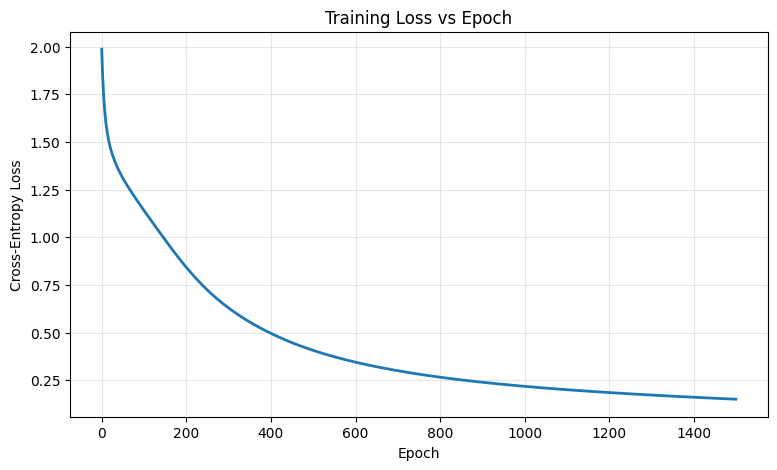

In [ ]:
# Plot how the cross-entropy loss changes during training.
# A decreasing curve indicates that the network is learning.
plt.figure(figsize=(9, 5))

plt.plot(
    loss_history,
    linewidth=2
)

plt.title(
    "Training Loss vs Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.grid(True, alpha=0.3)

plt.show()

## Part J: Training Accuracy Visualization

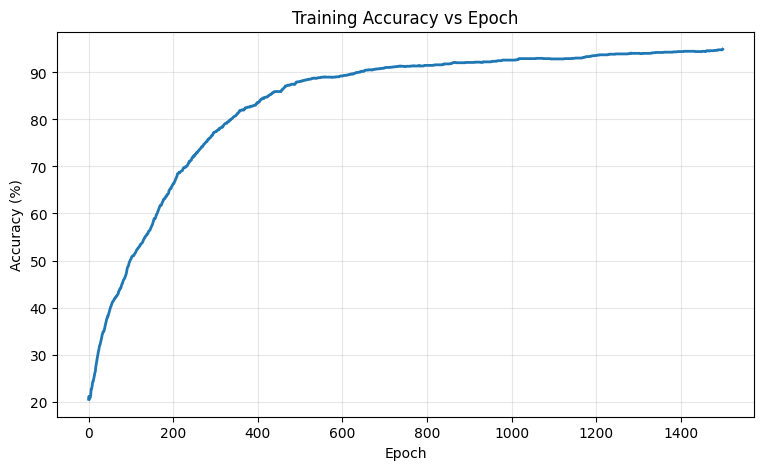

In [ ]:
# Plot the training accuracy over the 1500 epochs.
# Increasing accuracy indicates that the model is improving
# its classification performance.
plt.figure(figsize=(9, 5))

plt.plot(
    np.array(accuracy_history) * 100,
    linewidth=2
)

plt.title(
    "Training Accuracy vs Epoch"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.grid(True, alpha=0.3)

plt.show()

## Part K: Confusion Matrix Visualization

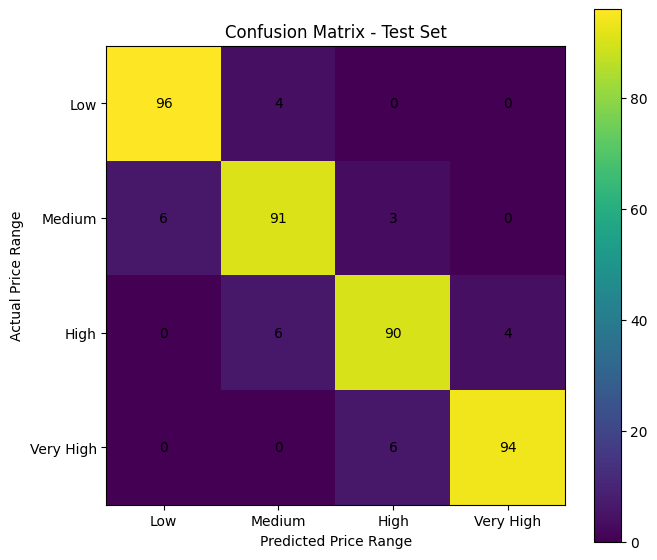

In [ ]:
# Display the confusion matrix visually.
# Diagonal values represent correctly classified phones.
plt.figure(figsize=(7, 6))

plt.imshow(
    confusion_matrix
)

plt.title(
    "Confusion Matrix - Test Set"
)

plt.xlabel(
    "Predicted Price Range"
)

plt.ylabel(
    "Actual Price Range"
)

plt.xticks(
    range(4),
    ["Low", "Medium", "High", "Very High"]
)

plt.yticks(
    range(4),
    ["Low", "Medium", "High", "Very High"]
)

# Write the numerical values inside the matrix cells.
for i in range(4):
    for j in range(4):
        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

## Part L: Sample Prediction

The trained network is used to classify one unseen smartphone from the test set.

The model produces four probabilities and selects the category with the highest probability.

In [ ]:
# Select one unseen sample from the test set.
sample_index = 0

sample = X_test[
    sample_index:sample_index + 1
]

# Run the sample through the trained neural network.
sample_probability, _ = forward_pass(
    sample,
    W1, b1,
    W2, b2,
    W3, b3
)

# Find the class with the highest probability.
predicted_class = np.argmax(
    sample_probability[0]
)

actual_class = y_test_labels[
    sample_index
]

price_names = [
    "Low Cost",
    "Medium Cost",
    "High Cost",
    "Very High Cost"
]

print(
    "Actual price range:   ",
    price_names[actual_class]
)

print(
    "Predicted price range:",
    price_names[predicted_class]
)

print("\nClass probabilities:")

for class_id, probability in enumerate(
    sample_probability[0]
):
    print(
        f"{price_names[class_id]:12s}: "
        f"{probability * 100:.2f}%"
    )

Actual price range:    Low Cost
Predicted price range: Low Cost

Class probabilities:
Low Cost    : 81.90%
Medium Cost : 18.10%
High Cost   : 0.00%
Very High Cost: 0.00%


## Part N: Conclusion

The neural network was successfully implemented from scratch using NumPy.

The model classifies smartphones into four price categories using 20 technical specifications. The complete learning pipeline was implemented manually, including preprocessing, forward propagation, activation functions, cross-entropy loss, backpropagation and gradient descent.

The loss and accuracy curves show the learning process, while the confusion matrix and class-wise metrics provide a detailed evaluation of the model on unseen test data.

This experiment demonstrates the internal working of a feedforward neural network without relying on TensorFlow, PyTorch, Keras or a pre-built neural-network classifier.

## Declaration

I, **Saumyajeet Singh Bhati**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

The code is uploaded on my GitHub repository account, and the repository link is provided below.

**GitHub Repository Link:** [https://github.com/Saumyajeet21/Gen_AI_Assig1]

**Signature:** Saumyajeet Singh Bhati